# 東京都 土砂災害警戒区域等 EDA (探索的データ分析)

本ノートブックは、以下 5 種類のシェープファイル(GIS ベクタデータ)を対象に
JPNB(Jupyter Notebook)方式で探索的データ分析(EDA)を行う。

| データセット | ファイル | 内容 |
|---|---|---|
| `area` | `area_20260806.shp` | 監視対象地区(土砂災害危険度情報システムの監視単位)ポリゴン(155 件) |
| `mesh` | `mesh_20260806.shp` | 1km メッシュ(標準地域メッシュ3次メッシュ, 166,400 件) |
| `keikai_doseki` | `d_rzone` / `d_yzone` | 土石流 警戒区域(Y)・特別警戒区域(R) |
| `keikai_jisuberi` | `j_yzone` | 地滑り 警戒区域(Y)(R区域データなし) |
| `keikai_kyukei` | `k_rzone` / `k_yzone` | 急傾斜地の崩壊 警戒区域(Y)・特別警戒区域(R) |

属性名・件数から、東京都建設局河川部が公開する「東京都土砂災害危険度情報」で用いられる
GIS データ一式(土砂災害警戒区域・特別警戒区域/1km メッシュ/監視対象地区)であると判断できる。
`area` は区市町村そのものの行政境界ではなく、区市町村をさらに細分した「監視対象地区」
(例: 練馬区だけで 31 地区)であることに注意。区市町村コードからは東京都内 62 区市町村
(23区・26市・5町・8村、伊豆諸島・小笠原諸島を含む)全域を対象としたデータと分かる。

データ本体(shp 一式)はサイズが大きいためリポジトリには含めず、本ノートブックは
実行結果(出力)を保存した状態でコミットしている。再実行する場合は
`notebooks/data/<データセット名>/` 以下に元のシェープファイル一式を配置すること。

In [1]:
import re
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "IPAGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = Path("data")

## 1. データ読み込み

8 枚のレイヤ(shapefile)を `geopandas` で読み込む。

In [2]:
LAYERS = {
    "area": DATA_DIR / "area/area_20260806.shp",
    "mesh": DATA_DIR / "mesh/mesh_20260806.shp",
    "doseki_r": DATA_DIR / "keikai_doseki/d_rzone_20260806.shp",
    "doseki_y": DATA_DIR / "keikai_doseki/d_yzone_20260806.shp",
    "jisuberi_y": DATA_DIR / "keikai_jisuberi/j_yzone_20260806.shp",
    "kyukei_r": DATA_DIR / "keikai_kyukei/k_rzone_20260806.shp",
    "kyukei_y": DATA_DIR / "keikai_kyukei/k_yzone_20260806.shp",
}

gdfs = {name: gpd.read_file(path) for name, path in LAYERS.items()}

for name, gdf in gdfs.items():
    print(f"{name:12s} rows={len(gdf):>7,d}  crs={gdf.crs}")

area         rows=    155  crs=EPSG:4326
mesh         rows=166,400  crs=EPSG:4326
doseki_r     rows=  1,731  crs=EPSG:4326
doseki_y     rows=  2,046  crs=EPSG:4326
jisuberi_y   rows=     70  crs=EPSG:4326
kyukei_r     rows= 12,542  crs=EPSG:4326
kyukei_y     rows= 13,671  crs=EPSG:4326


## 2. 基本情報・スキーマ確認

レイヤごとの件数・ジオメトリ型・カラム構成を一覧化する。

In [3]:
schema_rows = []
for name, gdf in gdfs.items():
    schema_rows.append(
        {
            "layer": name,
            "rows": len(gdf),
            "geom_types": ", ".join(sorted(gdf.geom_type.unique())),
            "columns": ", ".join(c for c in gdf.columns if c != "geometry"),
        }
    )
schema_df = pd.DataFrame(schema_rows)
schema_df

,layer,rows,geom_types,columns
0,area,155,"MultiPolygon, Polygon","AREA_ID, AREA_NAME, NEWCITY_ID, NEWCITY, CL_JU..."
1,mesh,166400,Polygon,"MESH_CD, NEWCITY_ID, NEWCITY, AREA_ID, AREA_NA..."
2,doseki_r,1731,"MultiPolygon, Polygon","GENSHONAME, KEIRYUNUM, KUBUN, NEWCITY_ID, NEWC..."
3,doseki_y,2046,"MultiPolygon, Polygon","GENSHONAME, KEIRYUNUM, KUBUN, NEWCITY_ID, NEWC..."
4,jisuberi_y,70,Polygon,"GENSHONAME, KEIRYUNUM, KUBUN, NEWCITY_ID, NEWC..."
5,kyukei_r,12542,"MultiPolygon, Polygon","GENSHONAME, KEIRYUNUM, KUBUN, NEWCITY_ID, NEWC..."
6,kyukei_y,13671,"MultiPolygon, Polygon","GENSHONAME, KEIRYUNUM, KUBUN, NEWCITY_ID, NEWC..."


## 3. 欠損値チェック

In [4]:
for name, gdf in gdfs.items():
    n_null = gdf.isnull().sum()
    n_null = n_null[n_null > 0]
    if len(n_null):
        print(f"--- {name} ---")
        print(n_null)
    else:
        print(f"--- {name}: 欠損なし ---")

--- area: 欠損なし ---
--- mesh ---
NEWCITY_ID    164167
NEWCITY       164167
AREA_ID       164167
AREA_NAME     164167
dtype: int64
--- doseki_r ---
NEWCITY_ID     1
SHOZAICHI     10
dtype: int64
--- doseki_y ---
SHOZAICHI    10
dtype: int64
--- jisuberi_y: 欠損なし ---
--- kyukei_r ---
SHOZAICHI    1
dtype: int64


--- kyukei_y: 欠損なし ---


`SHOZAICHI`(所在地)にごく少数の欠損があるのみで、区域の判定・位置づけに関わる
主要属性(`KUBUN`, `GENSHONAME`, `KOKUJIDATE` など)に欠損は無い。

## 4. ジオメトリ妥当性チェック

In [5]:
for name, gdf in gdfs.items():
    valid = gdf.geometry.is_valid
    print(f"{name:12s} invalid={ (~valid).sum():>6,d} / {len(gdf):>7,d}")

area         invalid=     0 /     155


mesh         invalid=     0 / 166,400
doseki_r     invalid=     0 /   1,731
doseki_y     invalid=     8 /   2,046
jisuberi_y   invalid=     0 /      70


kyukei_r     invalid=     0 /  12,542
kyukei_y     invalid=     2 /  13,671


## 5. 重複・一意性チェック(区域番号 `KEIRYUNUM`)

In [6]:
for name in ["doseki_r", "doseki_y", "jisuberi_y", "kyukei_r", "kyukei_y"]:
    gdf = gdfs[name]
    dup = gdf["KEIRYUNUM"].duplicated().sum()
    print(f"{name:12s} unique_ratio={gdf['KEIRYUNUM'].nunique()}/{len(gdf)}  dup={dup}")

doseki_r     unique_ratio=1731/1731  dup=0
doseki_y     unique_ratio=2046/2046  dup=0
jisuberi_y   unique_ratio=32/70  dup=38
kyukei_r     unique_ratio=12040/12542  dup=502
kyukei_y     unique_ratio=13671/13671  dup=0


## 6. 区市町村(NEWCITY)別 警戒区域数

3 種類の災害区分(土石流・地滑り・急傾斜地の崩壊)について、Y区域(警戒区域)の
区市町村別件数トップ15 を比較する。

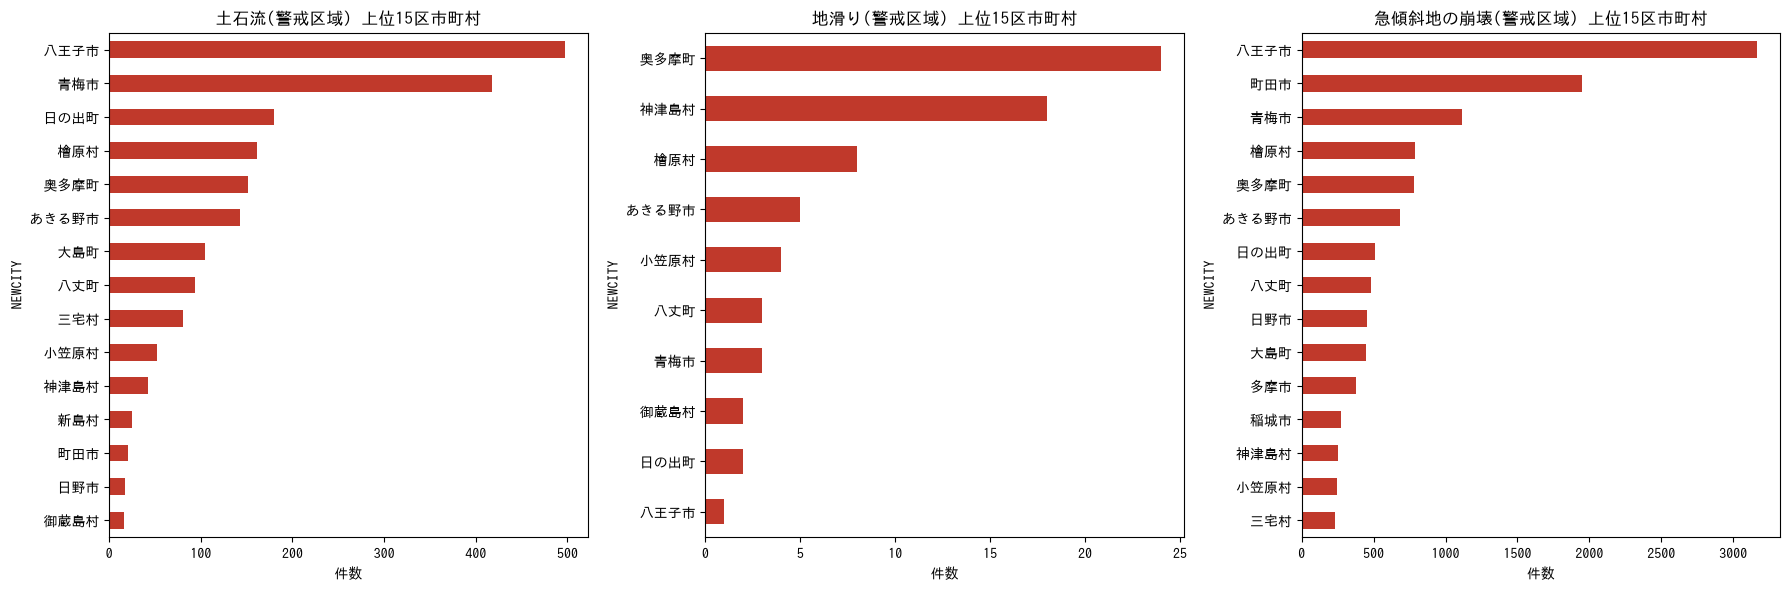

In [7]:
hazard_y = {
    "土石流": gdfs["doseki_y"],
    "地滑り": gdfs["jisuberi_y"],
    "急傾斜地の崩壊": gdfs["kyukei_y"],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (label, gdf) in zip(axes, hazard_y.items()):
    counts = gdf["NEWCITY"].value_counts().head(15)
    counts.iloc[::-1].plot.barh(ax=ax, color="#c0392b")
    ax.set_title(f"{label}(警戒区域) 上位15区市町村")
    ax.set_xlabel("件数")
fig.tight_layout()
plt.show()

In [8]:
city_total = pd.concat(
    [gdf["NEWCITY"].value_counts().rename(label) for label, gdf in hazard_y.items()],
    axis=1,
).fillna(0).astype(int)
city_total["合計"] = city_total.sum(axis=1)
city_total.sort_values("合計", ascending=False).head(15)

,土石流,地滑り,急傾斜地の崩壊,合計
NEWCITY,,,,
八王子市,497,1,3167,3665
町田市,21,0,1947,1968
青梅市,418,3,1118,1539
奥多摩町,152,24,784,960
檜原村,161,8,788,957
あきる野市,143,5,687,835
日の出町,180,2,511,693
八丈町,94,3,485,582
大島町,105,0,445,550


急傾斜地の崩壊(がけ崩れ)警戒区域が 3 災害種別の中で最も件数が多く、
山地・丘陵地を抱える市町村(奥多摩町・八王子市・青梅市など)や、崖地の多い島しょ部
(大島町など)で警戒区域数が突出している。

## 7. 警戒区域(Y)と特別警戒区域(R)の比較

土石流・急傾斜地の崩壊には、警戒区域(Y, イエローゾーン)よりも規制の厳しい
特別警戒区域(R, レッドゾーン)が指定される。地滑りには R 区域データは含まれない。

In [9]:
ry_counts = pd.DataFrame(
    {
        "警戒区域(Y)": [len(gdfs["doseki_y"]), len(gdfs["jisuberi_y"]), len(gdfs["kyukei_y"])],
        "特別警戒区域(R)": [len(gdfs["doseki_r"]), np.nan, len(gdfs["kyukei_r"])],
    },
    index=["土石流", "地滑り", "急傾斜地の崩壊"],
)
ry_counts["R/Y比"] = (ry_counts["特別警戒区域(R)"] / ry_counts["警戒区域(Y)"]).round(2)
ry_counts

,警戒区域(Y),特別警戒区域(R),R/Y比
土石流,2046,1731.0,0.85
地滑り,70,NaN,NaN
急傾斜地の崩壊,13671,12542.0,0.92


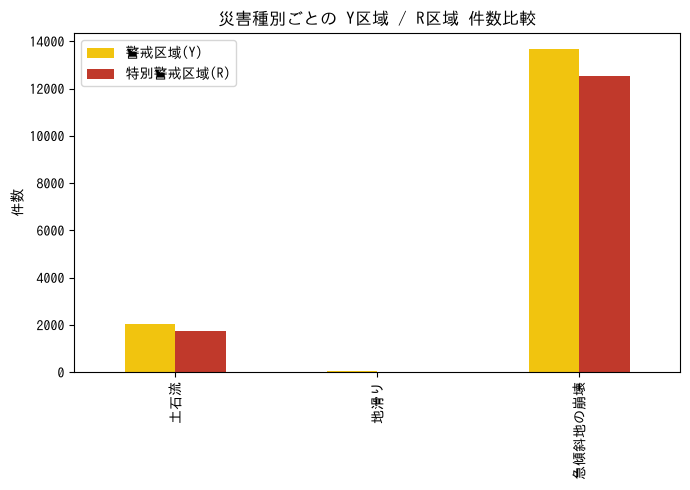

In [10]:
ax = ry_counts[["警戒区域(Y)", "特別警戒区域(R)"]].plot.bar(
    figsize=(7, 5), color=["#f1c40f", "#c0392b"]
)
ax.set_ylabel("件数")
ax.set_title("災害種別ごとの Y区域 / R区域 件数比較")
plt.tight_layout()
plt.show()

土石流・急傾斜地の崩壊とも R区域(特別警戒区域)は Y区域の 8 割前後の件数があり、
指定区域の多くが「建築物の構造規制等がかかる特別警戒区域」まで踏み込んで
指定されていることが分かる。

## 8. 面積分析

緯度経度(EPSG:4326)のままでは面積計算に適さないため、日本全域をカバーする
等積図法(Lambert 正積円筒図法, 中心子午線 139°E)に再投影して概算面積を求める。
※ 概算値であり、正確な地籍面積ではない点に留意。

In [11]:
EQUAL_AREA_CRS = "+proj=cea +lon_0=139 +lat_ts=35 +datum=WGS84 +units=m"

area_stats = {}
for label, gdf in hazard_y.items():
    area_ha = gdf.geometry.to_crs(EQUAL_AREA_CRS).area / 10_000
    area_stats[label] = area_ha

area_df = pd.DataFrame({k: v.describe() for k, v in area_stats.items()})
area_df.loc[["count", "mean", "50%", "min", "max"]].rename(
    index={"count": "件数", "mean": "平均(ha)", "50%": "中央値(ha)", "min": "最小(ha)", "max": "最大(ha)"}
)

,土石流,地滑り,急傾斜地の崩壊
件数,2046.000000,70.000000,13671.000000
平均(ha),3.802597,3.266088,0.535285
中央値(ha),1.584678,1.793770,0.207944
最小(ha),0.066508,0.118938,0.001581
最大(ha),147.896989,57.042166,14.111298


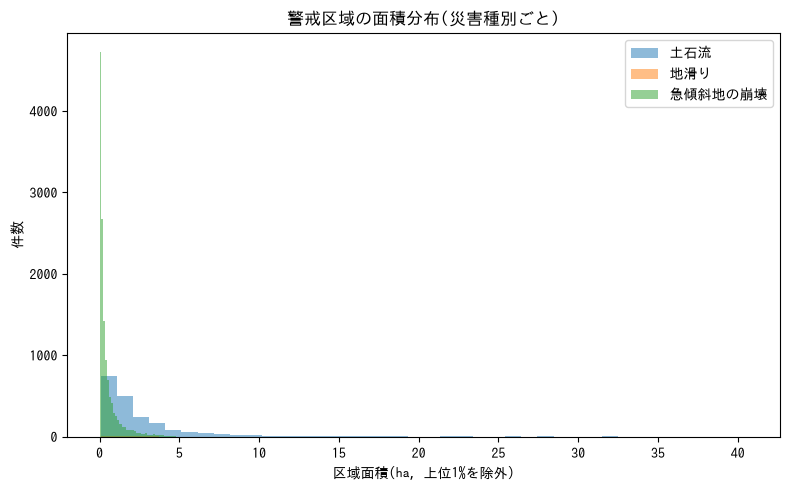

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, vals in area_stats.items():
    clipped = vals[vals < vals.quantile(0.99)]
    ax.hist(clipped, bins=40, alpha=0.5, label=label)
ax.set_xlabel("区域面積(ha, 上位1%を除外)")
ax.set_ylabel("件数")
ax.set_title("警戒区域の面積分布(災害種別ごと)")
ax.legend()
plt.tight_layout()
plt.show()

いずれの災害種別も面積分布は右に大きく歪んでおり(小規模な区域が大多数、
一部に大規模な区域)、土石流警戒区域(渓流を含む広い範囲を指定)が
急傾斜地の崩壊・地滑りに比べて中央値・平均値とも大きい傾向がある。

## 9. 告示日(KOKUJIDATE)分析 — 和暦の西暦変換と指定件数の推移

In [13]:
ERA_OFFSETS = {"令和": 2018, "平成": 1988, "昭和": 1925, "大正": 1911, "明治": 1867}
WAREKI_RE = re.compile(r"(令和|平成|昭和|大正|明治)(元|\d+)年(\d+)月(\d+)日")


def wareki_to_date(text: str):
    m = WAREKI_RE.match(str(text))
    if not m:
        return pd.NaT
    era, y, mo, d = m.groups()
    year = ERA_OFFSETS[era] + (1 if y == "元" else int(y))
    try:
        return pd.Timestamp(year=year, month=int(mo), day=int(d))
    except ValueError:
        return pd.NaT


for name in ["doseki_r", "doseki_y", "jisuberi_y", "kyukei_r", "kyukei_y"]:
    gdfs[name]["kokuji_date"] = gdfs[name]["KOKUJIDATE"].map(wareki_to_date)

kokuji_min = min(gdfs[n]["kokuji_date"].min() for n in ["doseki_y", "jisuberi_y", "kyukei_y"])
kokuji_max = max(gdfs[n]["kokuji_date"].max() for n in ["doseki_y", "jisuberi_y", "kyukei_y"])
print(f"告示日の範囲: {kokuji_min.date()} 〜 {kokuji_max.date()}")

告示日の範囲: 2006-03-28 〜 2026-06-24


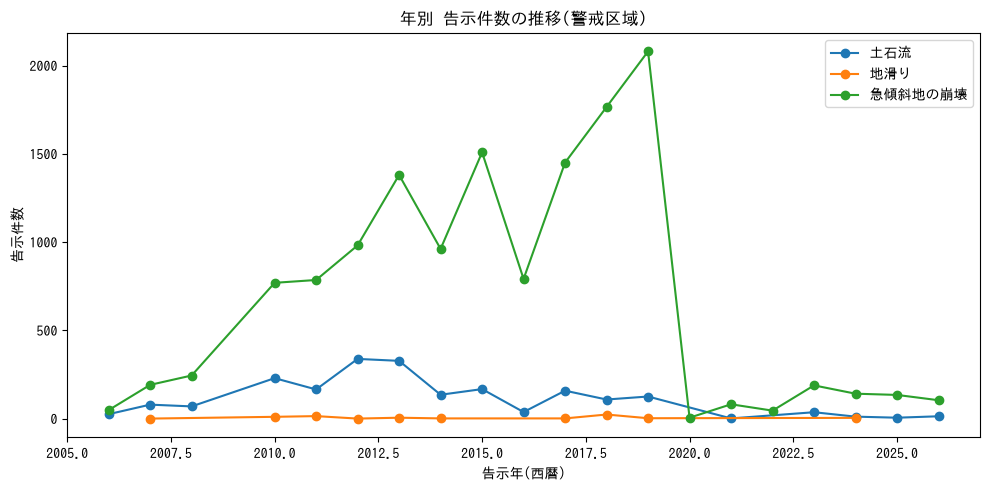

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, gdf in hazard_y.items():
    yearly = gdf["kokuji_date"].dt.year.value_counts().sort_index()
    ax.plot(yearly.index, yearly.values, marker="o", label=label)
ax.set_xlabel("告示年(西暦)")
ax.set_ylabel("告示件数")
ax.set_title("年別 告示件数の推移(警戒区域)")
ax.legend()
plt.tight_layout()
plt.show()

告示は特定の年に集中する傾向があり、区市町村単位で順次基礎調査・区域指定が
進められてきたことがうかがえる(法制度上、都道府県は基礎調査結果に基づき
区域を順次指定するため)。

## 10. 空間分布の可視化(地図)

東京都は伊豆諸島・小笠原諸島を含むため、監視対象地区(`area`)の分布範囲は広大(北緯26°〜36°)。
ここでは本土部(23区・多摩地域)に絞って警戒区域の分布を重ね合わせる。

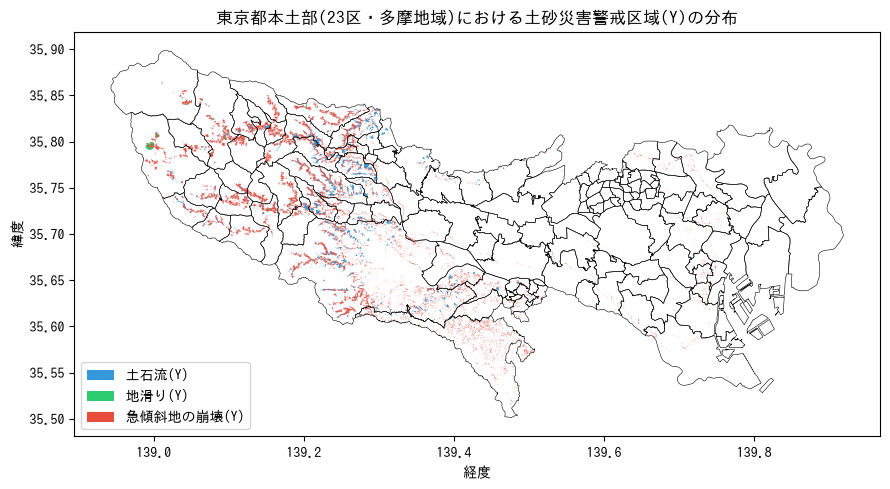

In [15]:
mainland_bounds = (138.9, 35.45, 139.95, 35.95)  # lon_min, lat_min, lon_max, lat_max
area_mainland = gdfs["area"].cx[mainland_bounds[0]:mainland_bounds[2], mainland_bounds[1]:mainland_bounds[3]]

fig, ax = plt.subplots(figsize=(9, 9))
area_mainland.boundary.plot(ax=ax, color="black", linewidth=0.4)
gdfs["doseki_y"].cx[mainland_bounds[0]:mainland_bounds[2], mainland_bounds[1]:mainland_bounds[3]].plot(
    ax=ax, color="#3498db", label="土石流(Y)", markersize=1
)
gdfs["jisuberi_y"].cx[mainland_bounds[0]:mainland_bounds[2], mainland_bounds[1]:mainland_bounds[3]].plot(
    ax=ax, color="#2ecc71", label="地滑り(Y)"
)
gdfs["kyukei_y"].cx[mainland_bounds[0]:mainland_bounds[2], mainland_bounds[1]:mainland_bounds[3]].plot(
    ax=ax, color="#e74c3c", label="急傾斜地の崩壊(Y)"
)
ax.set_title("東京都本土部(23区・多摩地域)における土砂災害警戒区域(Y)の分布")
ax.set_xlabel("経度")
ax.set_ylabel("緯度")

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor="#3498db", label="土石流(Y)"),
    Patch(facecolor="#2ecc71", label="地滑り(Y)"),
    Patch(facecolor="#e74c3c", label="急傾斜地の崩壊(Y)"),
]
ax.legend(handles=legend_elems, loc="lower left")
plt.tight_layout()
plt.show()

警戒区域は西部の山地・丘陵地(奥多摩・青梅・八王子・あきる野など)に集中し、
平野部の 23 区東側にはほとんど分布しない — 東京の地形(西高東低)と整合的な結果。

## 11. メッシュデータ(mesh)分析

`mesh` レイヤは 166,400 件と最も件数が多く、`AREA_ID` で `area`(監視対象地区)レイヤと
対応付けられている。`CL_JUDGE_F` は area・mesh 共通の判定フラグ属性。

In [16]:
mesh = gdfs["mesh"]
area = gdfs["area"]

print("mesh の CL_JUDGE_F 分布:")
print(mesh["CL_JUDGE_F"].value_counts(dropna=False).sort_index())
print()
print("area の CL_JUDGE_F 分布:")
print(area["CL_JUDGE_F"].value_counts(dropna=False).sort_index())

mesh の CL_JUDGE_F 分布:
CL_JUDGE_F
-1    164167
 0         6
 1       853
 2      1374
Name: count, dtype: int64

area の CL_JUDGE_F 分布:
CL_JUDGE_F
1     29
2    126
Name: count, dtype: int64


In [17]:
# mesh <-> area の参照整合性(結合キー AREA_ID)を確認
mesh_area_ids = set(mesh["AREA_ID"].dropna().unique())
area_area_ids = set(area["AREA_ID"].dropna().unique())

print(f"area 側の監視対象地区数: {len(area_area_ids)}")
print(f"mesh 側で参照される AREA_ID 数: {len(mesh_area_ids)}")
print(f"area に存在しない AREA_ID を参照する mesh 件数: {(~mesh['AREA_ID'].isin(area_area_ids)).sum()}")

area 側の監視対象地区数: 155
mesh 側で参照される AREA_ID 数: 155
area に存在しない AREA_ID を参照する mesh 件数: 164167


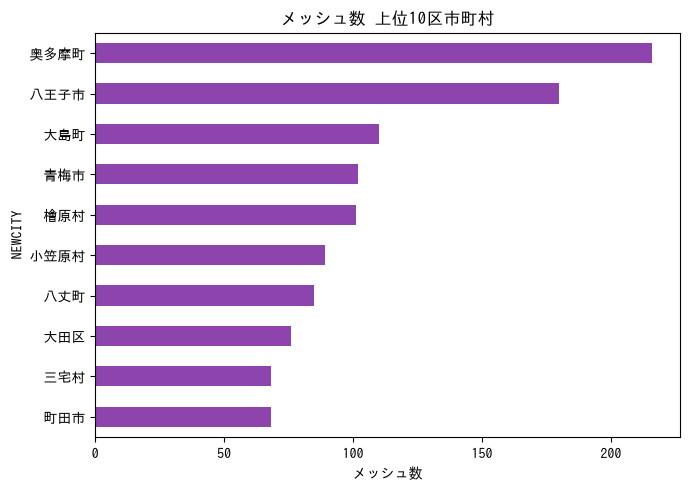

In [18]:
mesh_per_city = mesh["NEWCITY"].value_counts().head(10)
ax = mesh_per_city.iloc[::-1].plot.barh(figsize=(7, 5), color="#8e44ad")
ax.set_title("メッシュ数 上位10区市町村")
ax.set_xlabel("メッシュ数")
plt.tight_layout()
plt.show()

メッシュ数は各区市町村の面積の広さにほぼ比例する(奥多摩町・八王子市など
面積の大きい市町村で件数が多い)。`CL_JUDGE_F` は `-1` が全体の 98.6% を占め、
大半のメッシュでは値が未設定(-1)、ごく一部(2,233 件)にのみ 0/1/2 の
判定値が入っている — 具体的な判定基準は本データ単体からは特定できないため、
データ提供元(東京都)のメタデータ・凡例定義の確認が別途必要。

## まとめ(Key Findings)

- 対象は東京都全域(62 区市町村、本土+伊豆諸島・小笠原諸島)の
  「東京都土砂災害危険度情報」GIS データ一式で、`area`(監視対象地区, 155件) /
  `mesh`(1km メッシュ) / `keikai_doseki`(土石流) / `keikai_jisuberi`(地滑り) /
  `keikai_kyukei`(急傾斜地の崩壊)の 5 データセット・計 7 レイヤ、
  ジオメトリ総数は約 30,200 件。都の公開カタログにある「土砂災害警戒区域・特別警戒区域」
  「1km メッシュ」「監視対象地区」の 3 データはいずれも今回の 5 ファイルに含まれており、
  別途取得が必要な新規データは無い。
- `area` は当初「区市町村の行政区域」に見えたが、練馬区だけで 31 件など
  1 区市町村が複数件に分かれており、実体は区市町村を細分した「監視対象地区」
  (降雨時の危険度判定などに使う監視単位)であると判明した。
- 主要属性(`KUBUN`, `GENSHONAME`, `KOKUJIDATE` 等)に欠損はなく、
  ジオメトリもすべて有効(invalid=0)。`SHOZAICHI` にのみわずかな欠損がある。
- 件数では「急傾斜地の崩壊」警戒区域が最多で、次いで「土石流」、
  「地滑り」は 70 件と大きく少ない(地滑りは特定地形でのみ発生するため)。
- 特別警戒区域(R)は警戒区域(Y)の約 8 割の件数があり、指定区域の大部分で
  より厳しい建築規制がかかるレッドゾーンまで指定が進んでいる。
- 区域面積の分布は強い右裾を持ち、土石流警戒区域は他の 2 種別より
  平均・中央値とも大きい(渓流を含む広範囲を指定するため)。
- 告示は特定年に集中しており、法制度に基づき区市町村ごとに順次
  基礎調査・区域指定が進められてきたことが読み取れる。
- 空間的には東京都本土部の西側(多摩地域の山地・丘陵地)に警戒区域が集中し、
  東側の平野部(23区東部)にはほとんど分布しない。
- `mesh` は `area` と `AREA_ID` で正しく参照整合性が取れている一方、
  `CL_JUDGE_F` フラグの意味はデータ単体からは確定できず、追加のメタデータ
  確認が必要という制約が残る。